Hybrid Method 2 - Weighted RRF without Flat (cosine only) — NDCG & Recall in one figure


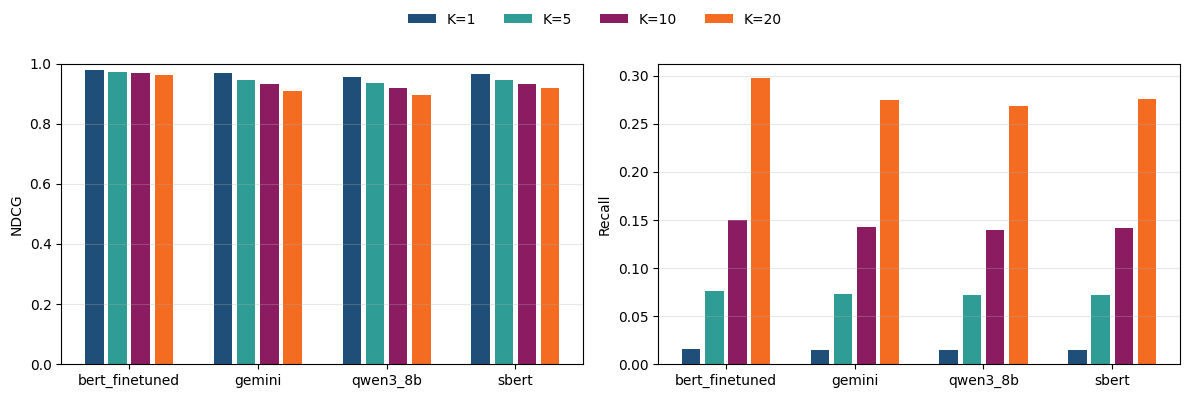

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Hybrid Weighted RRF without Flat
# Flat is kept only as exact-search baseline and is not used
# in the weighted fusion configuration.
# =========================================================

XLSX = "hybrid_weighted_rrf_no_flat_summary.xlsx"
SHEET = "Summary"

K_LIST = [1, 5, 10, 20]
TARGET_METRIC = "cosine"

df = pd.read_excel(XLSX, sheet_name=SHEET, engine="openpyxl")

#  cosine
df = df[df["metric"].astype(str).str.lower() == TARGET_METRIC].copy()
df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

if df.empty:
    raise ValueError("No rows found for metric='cosine' and K in [1,5,10,20]. Check the summary file.")

# pivot tables
pivot_ndcg = df.pivot_table(
    index="embedding",
    columns="K",
    values="ndcg@K",
    aggfunc="mean"
).sort_index()

pivot_recall = df.pivot_table(
    index="embedding",
    columns="K",
    values="recall@K",
    aggfunc="mean"
).sort_index()

missing_k = [k for k in K_LIST if k not in pivot_ndcg.columns]
if missing_k:
    raise ValueError(f"Missing K values in summary file: {missing_k}")

embeddings = pivot_ndcg.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

colors = ["#1f4e79", "#2f9c95", "#8b1c62", "#f36c21"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---------- NDCG ----------
ax = axes[0]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_ndcg[K].values,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

ax.set_ylabel("NDCG")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# ---------- Recall ----------
ax = axes[1]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_recall[K].values,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

ax.set_ylabel("Recall")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.grid(axis="y", alpha=0.3)

# legend 
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()



In [ ]:
FIG_NAME_PNG = "Hybrid2_Weighted_RRF_NoFlat_Search_NDCG_Recall_cosine.png"
FIG_NAME_PDF = "Hybrid2_Weighted_RRF_NoFlat_Search_NDCG_Recall_cosine.pdf"

fig.savefig(
    FIG_NAME_PNG,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    FIG_NAME_PDF,
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME_PNG)
print("Figure saved as:", FIG_NAME_PDF)



 Figure saved as: Hybrid2_Weighted_RRF_NoFlat_Search_NDCG_Recall_cosine.png
 Figure saved as: Hybrid2_Weighted_RRF_NoFlat_Search_NDCG_Recall_cosine.pdf


Extract the Final Precision and MRR Table for Hybrid Weighted RRF Without Flat

In [ ]:
import pandas as pd

SUMMARY_XLSX = "hybrid_weighted_rrf_no_flat_summary.xlsx"

df = pd.read_excel(SUMMARY_XLSX, sheet_name="Summary", engine="openpyxl")

# فقط cosine
df = df[df["metric"].astype(str).str.lower() == "cosine"].copy()
df["K"] = df["K"].astype(int)

# Precision table
prec = df.pivot_table(
    index="embedding",
    columns="K",
    values="precision@K",
    aggfunc="mean"
)

prec = prec[[k for k in [1, 5, 10, 20] if k in prec.columns]]

mrr = df.groupby("embedding")["mrr@K"].mean()

table = prec.copy()
table["MRR"] = mrr

print(table.round(4))



K                    1       5      10      20     MRR
embedding                                             
bert_finetuned  0.9793  0.9700  0.9647  0.9588  0.9811
gemini          0.9677  0.9399  0.9213  0.8956  0.9706
qwen3_8b        0.9565  0.9285  0.9075  0.8785  0.9601
sbert           0.9647  0.9376  0.9226  0.9079  0.9686


latex

In [4]:
print(table.round(4).to_latex())



\begin{tabular}{lrrrrr}
\toprule
K & 1 & 5 & 10 & 20 & MRR \\
embedding &  &  &  &  &  \\
\midrule
bert_finetuned & 0.979300 & 0.970000 & 0.964700 & 0.958800 & 0.981100 \\
gemini & 0.967700 & 0.939900 & 0.921300 & 0.895600 & 0.970600 \\
qwen3_8b & 0.956500 & 0.928500 & 0.907500 & 0.878500 & 0.960100 \\
sbert & 0.964700 & 0.937600 & 0.922600 & 0.907900 & 0.968600 \\
\bottomrule
\end{tabular}

